<a href="https://colab.research.google.com/github/morgan-pineapplepancake/skills-introduction-to-github/blob/main/%E3%80%8CRLCpinn_ipynb%E3%80%8D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

引入模型

In [ ]:
import tensorflow as tf
from tensorflow.python.ops import math_ops
from tensorflow.keras import backend as K
import numpy as np
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import math

訓練參數設定

In [ ]:
batch_size = 64
epochs = 1000
optimizer = Adam(learning_rate=0.001)
weight_init = RandomNormal()

定義邊界條件

In [ ]:
#boundary condition:
R = 1.2 #resistence,kohm
L = 1.5 #inductance,H
C = 0.3 #capacitance,F
VC_0 = 12.0 #initial_volt,V
#initial time/current condition:
t_init = np.array([0.0])
i_init = np.array([0.0])
#initial time/voltage condition:
t_initv = np.array([0.0])
v_initv = np.array([VC_0])
#colocation points
t_col = np.arange(0,60.0,0.3)

神經層設計

In [ ]:
input = tf.keras.Input(shape=(1,))
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init, kernel_regularizer=None)(input)
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init, kernel_regularizer=None)(x)
output = layers.Dense(1, activation='linear', kernel_initializer=weight_init, kernel_regularizer=None)(x)
model = tf.keras.Model(inputs=input, outputs=output)

定義損失函數

In [ ]:
def step(t_col, t_init, i_init, t_initv, v_initv):
  with tf.GradientTape(persistent=True) as tape:
    #Define loss function with boundary conditions
    #First loss
    pred_init = model(t_init)
    init_loss = math_ops.squared_difference(pred_init, i_init)
    #Second loss
    t_initv = tf.convert_to_tensor(t_initv)
    t_initv = tf.reshape(t_initv, [-1, 1])
    t_initv = tf.Variable(t_initv, name='t_initv')
    pred_initv = model(t_initv)
    dfdx = tape.gradient(pred_initv, t_initv)
    v = dfdx * tf.cast(L, tf.float64)
    init_lossv = math_ops.squared_difference(v, v_initv)
    init_lossv = tf.cast(init_lossv, tf.float32)
    #PINN loss
    with tf.GradientTape(persistent= True) as tape2:
      t_col = tf.convert_to_tensor(t_col)
      t_col = tf.reshape(t_col, [-1, 1])
      t_col = tf.Variable(t_col, name='t_coloc')
      pred_q = model(t_col)
      dqdt = tape2.gradient(pred_q, t_col)
    dq2dt = tape.gradient(dqdt, t_col)
    pred_q = tf.cast(pred_q, tf.float64)
    #RLC equation
    Residual = dq2dt + dqdt * (R/L) + pred_q *(L * C)
    #Substitude the predicted value into the equation
    pinn_loss = K.mean(math_ops.square(Residual), axis= -1)
    pinn_loss = tf.cast(pinn_loss, tf.float32)

    #combine all loss
    model_loss = init_loss + init_lossv + pinn_loss

    #backwards propagation
    trainable = model.trainable_variables
    grads = tape.gradient(model_loss, trainable)

    #Update model
    optimizer.apply_gradients(zip(grads, trainable))


訓練迭帶設計

In [ ]:
batch_per_epoch = math.floor(len(t_col)/batch_size)
for epoch in range(epochs):
  for i in range(batch_per_epoch):
    n = i * batch_size
    step(t_col[n:n + batch_size], t_init, i_init, t_initv, v_initv)

RLC實際方程解(對照組)

In [ ]:
#compare with RLC test
numb_of_pts = 600
alpha = R / (L * 2)


t_test = np.arange(numb_of_pts * 0.1).astype(np.float32)
t_test_in = t_test.reshape(-1, 1) #makes sure shape (60,1)
i_test = model(t_test_in, training = False).numpy().reshape(-1)
i_calc = (VC_0 / L) * t_test_in * np.exp(-1 * alpha * t_test_in) *(6/7)

機器學習結果與對照組作圖比較

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


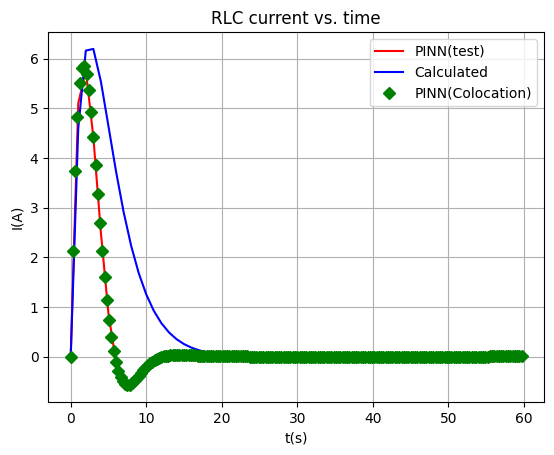

In [ ]:
plt.plot(t_test, i_test, 'r', label = 'PINN(test)')
plt.plot(t_test, i_calc, 'b', label = 'Calculated')
plt.plot(t_col, model.predict(t_col), 'Dg', label = 'PINN(Colocation)')
plt.title('RLC current vs. time')
plt.xlabel('t(s)')
plt.ylabel('I(A)')
plt.legend()
plt.grid()
plt.show()